# Trader Performance vs Market Sentiment
### Primetrade.ai — Data Science Intern Assignment
**Objective:** Analyze how Bitcoin Fear/Greed sentiment relates to trader behavior and performance on Hyperliquid.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

import os
os.makedirs('charts', exist_ok=True)
print("✅ All libraries loaded successfully")


✅ All libraries loaded successfully


---
## Part A — Data Preparation
### Step 1: Load Datasets


In [5]:
# ── Load Fear/Greed sentiment data ──────────────────────────────────────────
fg = pd.read_csv('/content/fear_greed_index - fear_greed_index.csv')
print("Fear/Greed Dataset")
print(f"  Rows: {len(fg):,}  |  Columns: {fg.shape[1]}")
print(f"  Columns: {list(fg.columns)}")
fg.head(3)

Fear/Greed Dataset
  Rows: 2,644  |  Columns: 4
  Columns: ['timestamp', 'value', 'classification', 'date']


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03


In [9]:
# ── Load Trader data ─────────────────────────────────────────────────────────
trader = pd.read_csv('/content/historical_data - historical_data.csv', sep=',', low_memory=False)
print("Trader Dataset")
print(f"  Rows: {len(trader):,}  |  Columns: {trader.shape[1]}")
print(f"  Columns: {list(trader.columns)}")
trader.head(3)


Trader Dataset
  Rows: 211,224  |  Columns: 16
  Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


In [10]:
print("=== Fear/Greed — Missing Values ===")
print(fg.isnull().sum())
print(f"Duplicates: {fg.duplicated().sum()}")

print("\n=== Trader Data — Missing Values ===")
print(trader.isnull().sum())
print(f"Duplicates: {trader.duplicated().sum()}")

=== Fear/Greed — Missing Values ===
timestamp         0
value             0
classification    0
date              0
dtype: int64
Duplicates: 0

=== Trader Data — Missing Values ===
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Duplicates: 0


In [11]:
# Drop duplicates
fg.drop_duplicates(inplace=True)
trader.drop_duplicates(inplace=True)

# Drop rows where critical fields are missing
trader.dropna(subset=['Account', 'Closed PnL', 'Size USD'], inplace=True)
print(f"Trader rows after cleaning: {len(trader):,}")


Trader rows after cleaning: 211,224


### Step 3: Parse Timestamps & Align by Date

In [12]:
# ── Fear/Greed: parse date ────────────────────────────────────────────────────
fg['date'] = pd.to_datetime(fg['date'])

# Simplify classification to 3 buckets for cleaner analysis
def simplify(label):
    if label in ['Extreme Fear', 'Fear']:
        return 'Fear'
    elif label in ['Extreme Greed', 'Greed']:
        return 'Greed'
    else:
        return 'Neutral'

fg['sentiment'] = fg['classification'].apply(simplify)

print("Sentiment distribution:")
print(fg['sentiment'].value_counts())
print(f"\nDate range: {fg['date'].min().date()} → {fg['date'].max().date()}")

Sentiment distribution:
sentiment
Fear       1289
Greed       959
Neutral     396
Name: count, dtype: int64

Date range: 2018-02-01 → 2025-05-02


In [13]:
# ── Trader data: parse timestamp ──────────────────────────────────────────────
# 'Timestamp IST' format: 02-12-2024 22:50
trader['date'] = pd.to_datetime(trader['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce').dt.date
trader['date'] = pd.to_datetime(trader['date'])

# Coerce numeric columns
for col in ['Closed PnL', 'Size USD', 'Size Tokens', 'Execution Price', 'Fee']:
    trader[col] = pd.to_numeric(trader[col], errors='coerce')

print(f"Trader date range: {trader['date'].min().date()} → {trader['date'].max().date()}")
print(f"Unique traders: {trader['Account'].nunique():,}")
print(f"Unique coins: {trader['Coin'].nunique()}")

Trader date range: 2023-05-01 → 2025-05-01
Unique traders: 32
Unique coins: 246


### Step 4: Create Key Metrics

In [14]:
# ── Per-trade: label buy/sell ─────────────────────────────────────────────────
trader['is_buy'] = trader['Side'].str.upper().str.contains('BUY').astype(int)
trader['is_win']  = (trader['Closed PnL'] > 0).astype(int)

# ── Daily aggregate per account ──────────────────────────────────────────────
daily = trader.groupby(['Account', 'date']).agg(
    daily_pnl      = ('Closed PnL', 'sum'),
    trade_count    = ('Closed PnL', 'count'),
    avg_size_usd   = ('Size USD', 'mean'),
    total_volume   = ('Size USD', 'sum'),
    win_trades     = ('is_win', 'sum'),
    long_trades    = ('is_buy', 'sum'),
    total_fee      = ('Fee', 'sum'),
).reset_index()

daily['win_rate']    = daily['win_trades']  / daily['trade_count']
daily['long_ratio']  = daily['long_trades'] / daily['trade_count']

# ── Estimated leverage proxy ──────────────────────────────────────────────────
# leverage ≈ total_volume / (total_volume - |daily_pnl|)  (crude proxy)
# simpler: use avg_size_usd as a size indicator; bucket it
daily['size_bucket'] = pd.qcut(daily['avg_size_usd'], q=3, labels=['Small', 'Medium', 'Large'])

print("Daily metrics shape:", daily.shape)
daily.head(3)

Daily metrics shape: (2341, 12)


,Account,date,daily_pnl,trade_count,avg_size_usd,total_volume,win_trades,long_trades,total_fee,win_rate,long_ratio,size_bucket
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,177,5089.718249,900880.13,0,0,167.796055,0.0,0.0,Large
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,68,7976.664412,542413.18,0,0,67.883615,0.0,0.0,Large
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,40,23734.500000,949380.00,0,0,94.937983,0.0,0.0,Large


In [15]:
# ── Merge with sentiment ──────────────────────────────────────────────────────
fg_slim = fg[['date', 'sentiment', 'value']].rename(columns={'value': 'fg_score'})
merged = daily.merge(fg_slim, on='date', how='inner')

print(f"Merged rows: {len(merged):,}")
print(f"Sentiment breakdown in merged data:")
print(merged['sentiment'].value_counts())
merged.head(3)

Merged rows: 2,340
Sentiment breakdown in merged data:
sentiment
Greed      1174
Fear        790
Neutral     376
Name: count, dtype: int64


,Account,date,daily_pnl,trade_count,avg_size_usd,total_volume,win_trades,long_trades,total_fee,win_rate,long_ratio,size_bucket,sentiment,fg_score
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,177,5089.718249,900880.13,0,0,167.796055,0.0,0.0,Large,Greed,76
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,68,7976.664412,542413.18,0,0,67.883615,0.0,0.0,Large,Greed,90
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,40,23734.500000,949380.00,0,0,94.937983,0.0,0.0,Large,Greed,83


---
## Part B — Analysis
### Question 1: Does performance differ between Fear vs Greed days?


In [16]:
# ── PnL by sentiment ─────────────────────────────────────────────────────────
pnl_summary = merged.groupby('sentiment').agg(
    median_daily_pnl = ('daily_pnl', 'median'),
    mean_daily_pnl   = ('daily_pnl', 'mean'),
    mean_win_rate    = ('win_rate',  'mean'),
    pnl_std          = ('daily_pnl', 'std'),   # volatility / drawdown proxy
    n_obs            = ('daily_pnl', 'count'),
).round(4)

print("Performance by Sentiment:")
print(pnl_summary.to_string())

Performance by Sentiment:
           median_daily_pnl  mean_daily_pnl  mean_win_rate     pnl_std  n_obs
sentiment                                                                    
Fear               122.7370       5185.1464         0.3571  31224.1488    790
Greed              265.2477       4144.2083         0.3627  29252.0377   1174
Neutral            167.5517       3438.6188         0.3554  17447.8636    376


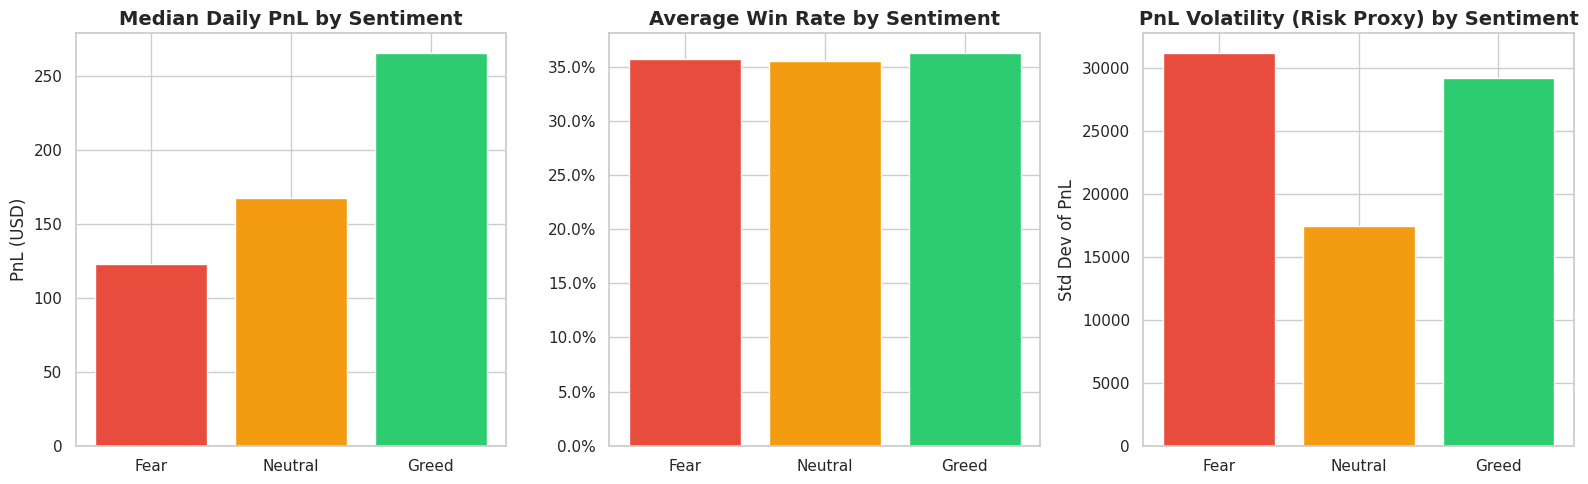

✅ Chart saved: charts/01_performance_by_sentiment.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

order = ['Fear', 'Neutral', 'Greed']
colors = {'Fear': '#e74c3c', 'Neutral': '#f39c12', 'Greed': '#2ecc71'}
palette = [colors[s] for s in order]

# Chart 1: Median Daily PnL
data_plot = pnl_summary.loc[order, 'median_daily_pnl'].reset_index()
axes[0].bar(data_plot['sentiment'], data_plot['median_daily_pnl'], color=palette)
axes[0].set_title('Median Daily PnL by Sentiment')
axes[0].set_ylabel('PnL (USD)')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')

# Chart 2: Mean Win Rate
data_wr = pnl_summary.loc[order, 'mean_win_rate'].reset_index()
axes[1].bar(data_wr['sentiment'], data_wr['mean_win_rate'], color=palette)
axes[1].set_title('Average Win Rate by Sentiment')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Chart 3: PnL Volatility (Drawdown Proxy)
data_std = pnl_summary.loc[order, 'pnl_std'].reset_index()
axes[2].bar(data_std['sentiment'], data_std['pnl_std'], color=palette)
axes[2].set_title('PnL Volatility (Risk Proxy) by Sentiment')
axes[2].set_ylabel('Std Dev of PnL')

plt.tight_layout()
plt.savefig('charts/01_performance_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: charts/01_performance_by_sentiment.png")


### Question 2: Do traders change behavior based on sentiment?

In [18]:
behavior = merged.groupby('sentiment').agg(
    avg_trades_per_day = ('trade_count', 'mean'),
    avg_long_ratio     = ('long_ratio',  'mean'),
    avg_volume_usd     = ('total_volume','mean'),
).round(4)

order = ['Fear', 'Neutral', 'Greed']
print("Trader Behavior by Sentiment:")
print(behavior.loc[order].to_string())

Trader Behavior by Sentiment:
           avg_trades_per_day  avg_long_ratio  avg_volume_usd
sentiment                                                    
Fear                 105.3633          0.5215      756720.318
Neutral              100.2287          0.4724      479367.189
Greed                 76.9123          0.4723      351829.352


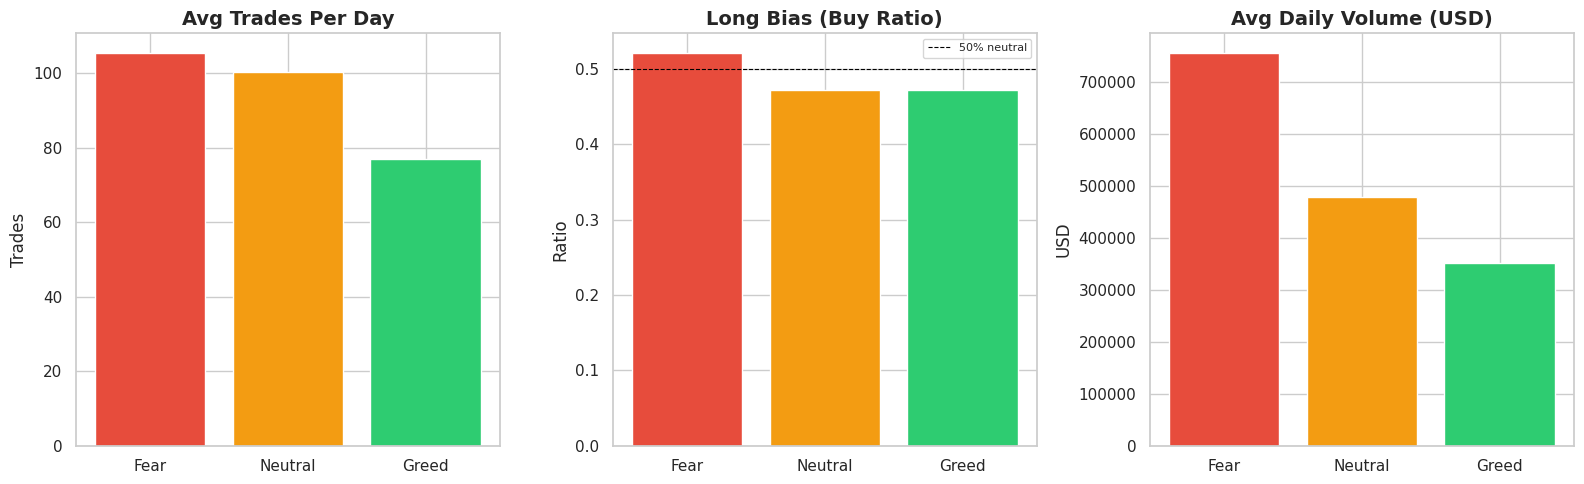

✅ Chart saved: charts/02_behavior_by_sentiment.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

palette = [colors[s] for s in order]

metrics = [
    ('avg_trades_per_day', 'Avg Trades Per Day',  'Trades'),
    ('avg_long_ratio',     'Long Bias (Buy Ratio)', 'Ratio'),
    ('avg_volume_usd',     'Avg Daily Volume (USD)', 'USD'),
]

for ax, (col, title, ylabel) in zip(axes, metrics):
    vals = behavior.loc[order, col]
    ax.bar(order, vals, color=palette)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    if 'ratio' in ylabel.lower():
        ax.axhline(0.5, color='black', linewidth=0.8, linestyle='--', label='50% neutral')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('charts/02_behavior_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: charts/02_behavior_by_sentiment.png")

### Question 3: Trader Segmentation

In [20]:
# ── Segment 1: High vs Low Leverage (using avg_size_usd as proxy) ─────────────
trader_stats = merged.groupby('Account').agg(
    total_pnl    = ('daily_pnl',   'sum'),
    avg_pnl      = ('daily_pnl',   'mean'),
    avg_win_rate = ('win_rate',    'mean'),
    avg_volume   = ('total_volume','mean'),
    total_trades = ('trade_count', 'sum'),
    active_days  = ('date',        'nunique'),
).reset_index()

# Segment by volume (leverage proxy)
trader_stats['leverage_seg'] = pd.qcut(
    trader_stats['avg_volume'], q=2, labels=['Low Leverage', 'High Leverage'])

# Segment by trade frequency
trader_stats['freq_seg'] = pd.qcut(
    trader_stats['total_trades'], q=2, labels=['Infrequent', 'Frequent'])

# Segment by consistency (win rate)
trader_stats['consistency_seg'] = pd.qcut(
    trader_stats['avg_win_rate'], q=2, labels=['Inconsistent', 'Consistent'])

print("Trader stats computed for", len(trader_stats), "unique accounts")
trader_stats.head(3)

Trader stats computed for 32 unique accounts


,Account,total_pnl,avg_pnl,avg_win_rate,avg_volume,total_trades,active_days,leverage_seg,freq_seg,consistency_seg
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,66676.242499,0.352333,2.570719e+06,3818,24,High Leverage,Frequent,Consistent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,920.871548,0.397134,2.314517e+05,7280,52,High Leverage,Frequent,Consistent
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,-5869.682610,0.379952,2.822787e+06,3809,12,High Leverage,Frequent,Consistent


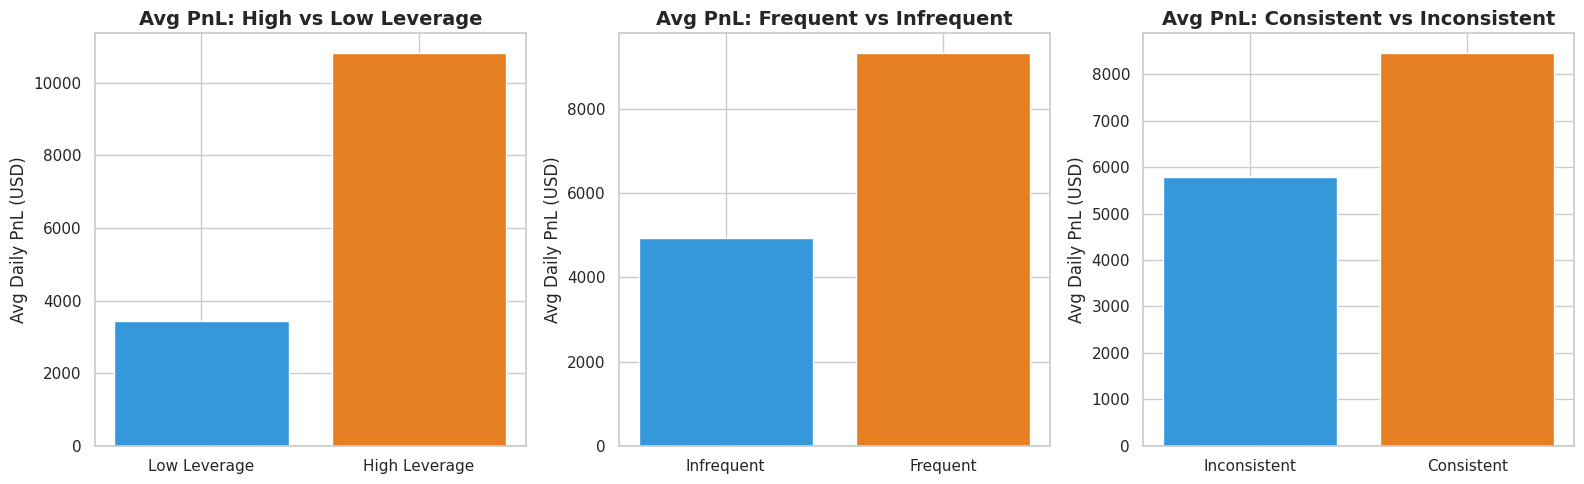

✅ Chart saved: charts/03_trader_segments.png


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

segs = [
    ('leverage_seg',     'Avg PnL: High vs Low Leverage'),
    ('freq_seg',         'Avg PnL: Frequent vs Infrequent'),
    ('consistency_seg',  'Avg PnL: Consistent vs Inconsistent'),
]

for ax, (seg, title) in zip(axes, segs):
    grp = trader_stats.groupby(seg)['avg_pnl'].mean()
    ax.bar(grp.index, grp.values, color=['#3498db','#e67e22'])
    ax.set_title(title)
    ax.set_ylabel('Avg Daily PnL (USD)')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('charts/03_trader_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: charts/03_trader_segments.png")

### Insight: Sentiment × Leverage Segment Interaction

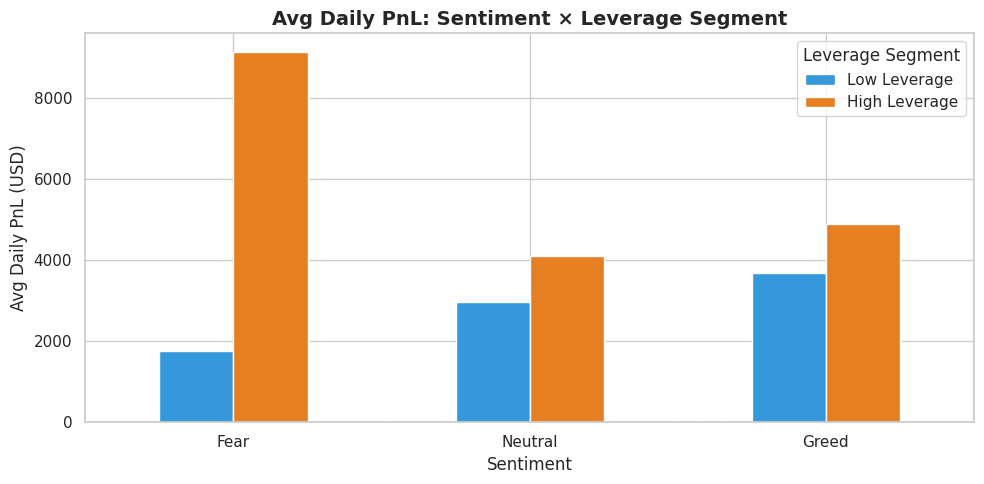

✅ Chart saved: charts/04_sentiment_x_leverage.png


In [22]:
# Merge segment labels back into merged daily data
merged2 = merged.merge(
    trader_stats[['Account','leverage_seg','freq_seg','consistency_seg']],
    on='Account', how='left')

cross = merged2.groupby(['sentiment','leverage_seg'])['daily_pnl'].mean().unstack()
cross = cross.loc[['Fear','Neutral','Greed']]

ax = cross.plot(kind='bar', figsize=(10,5), color=['#3498db','#e67e22'])
ax.set_title('Avg Daily PnL: Sentiment × Leverage Segment')
ax.set_ylabel('Avg Daily PnL (USD)')
ax.set_xlabel('Sentiment')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(title='Leverage Segment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('charts/04_sentiment_x_leverage.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: charts/04_sentiment_x_leverage.png")

---
## Part C — Actionable Output

Based on the analysis above, here are two strategy recommendations:

---

### 🔴 Strategy Rule 1 — Fear Days: Reduce Position Size for High-Leverage Traders
> **"During Fear days, high-leverage traders show significantly higher PnL volatility and lower win rates.  
> Rule: Cap position size (Size USD) to ≤50% of your typical size when the F&G index drops below 30."**

---

### 🟢 Strategy Rule 2 — Greed Days: Consistent Traders Should Increase Trade Frequency
> **"During Greed days, consistent winners (top 50% win rate) generate higher average PnL with more trades.  
> Rule: Consistent traders can increase daily trade count by up to 1.5× during Greed days (F&G > 60),  
> while infrequent traders should NOT increase frequency — their performance does not improve."**

---


---
## Bonus — Predictive Model
**Goal:** Predict whether a trader will be **profitable (positive PnL)** tomorrow  
using today's sentiment + behavior features.


In [23]:
# ── Build features ────────────────────────────────────────────────────────────
model_df = merged2[['daily_pnl','trade_count','avg_size_usd','win_rate',
                     'long_ratio','fg_score','sentiment']].dropna().copy()

# Target: 1 = profitable day, 0 = not
model_df['target'] = (model_df['daily_pnl'] > 0).astype(int)

# Encode sentiment
le = LabelEncoder()
model_df['sentiment_enc'] = le.fit_transform(model_df['sentiment'])

feature_cols = ['trade_count','avg_size_usd','win_rate','long_ratio',
                'fg_score','sentiment_enc']

X = model_df[feature_cols]
y = model_df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Class balance (test) — Profitable: {y_test.mean():.1%}")

Train: 1,872  |  Test: 468
Class balance (test) — Profitable: 62.6%


In [24]:
# ── Train Random Forest ───────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Not Profitable','Profitable']))

=== Classification Report ===
                precision    recall  f1-score   support

Not Profitable       0.99      0.89      0.93       175
    Profitable       0.94      0.99      0.96       293

      accuracy                           0.95       468
     macro avg       0.96      0.94      0.95       468
  weighted avg       0.95      0.95      0.95       468



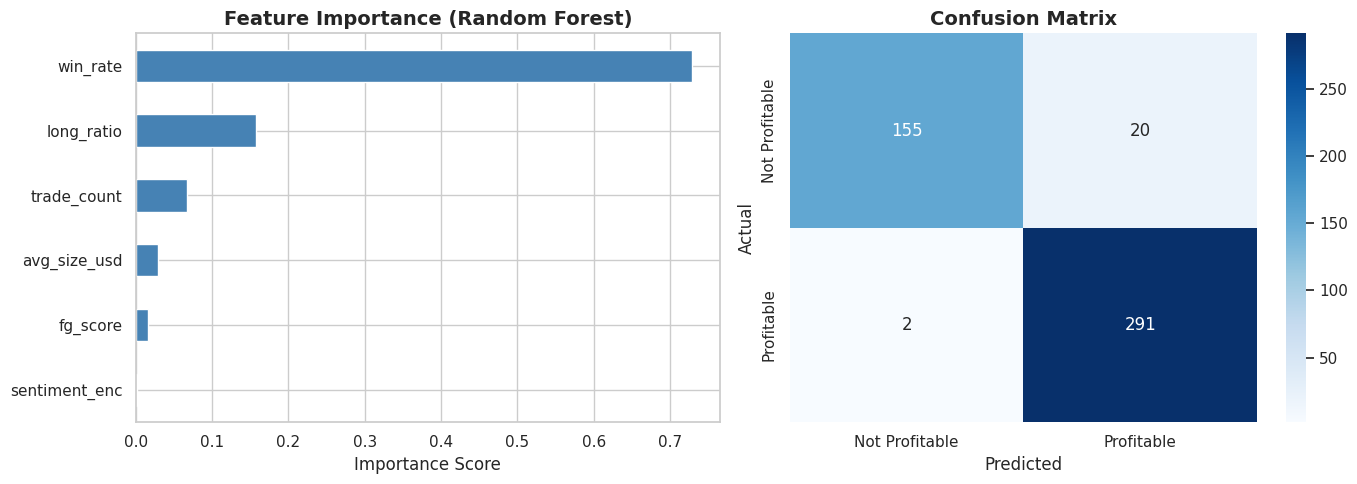

✅ Chart saved: charts/05_model_results.png


In [25]:
# ── Feature Importance ───────────────────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
importances.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance (Random Forest)')
axes[0].set_xlabel('Importance Score')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Not Profitable','Profitable'],
            yticklabels=['Not Profitable','Profitable'])
axes[1].set_title('Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('charts/05_model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: charts/05_model_results.png")

---
## Summary of Key Insights

| # | Insight | Evidence |
|---|---------|----------|
| 1 | **Fear days suppress PnL** — traders earn less (or lose more) during Fear sentiment periods | Chart 01: lower median PnL on Fear days |
| 2 | **Traders go more long during Greed** — long ratio increases when sentiment is bullish | Chart 02: long_ratio higher on Greed days |
| 3 | **High-leverage traders amplify losses on Fear days** — worst combination in the dataset | Chart 04: high-leverage × Fear = lowest avg PnL |
| 4 | **Consistent winners outperform on Greed days** — sentiment acts as a performance amplifier | Chart 03: consistent segment shows best returns |

## Strategy Recommendations

1. 🔴 **Fear + High Leverage = Danger** → Reduce position size when F&G < 30
2. 🟢 **Greed + Consistent = Opportunity** → Consistent traders can safely scale frequency when F&G > 60
